Сохранено: /content/experiments_by_n.png
Сохранено: /content/experiments_by_n.svg


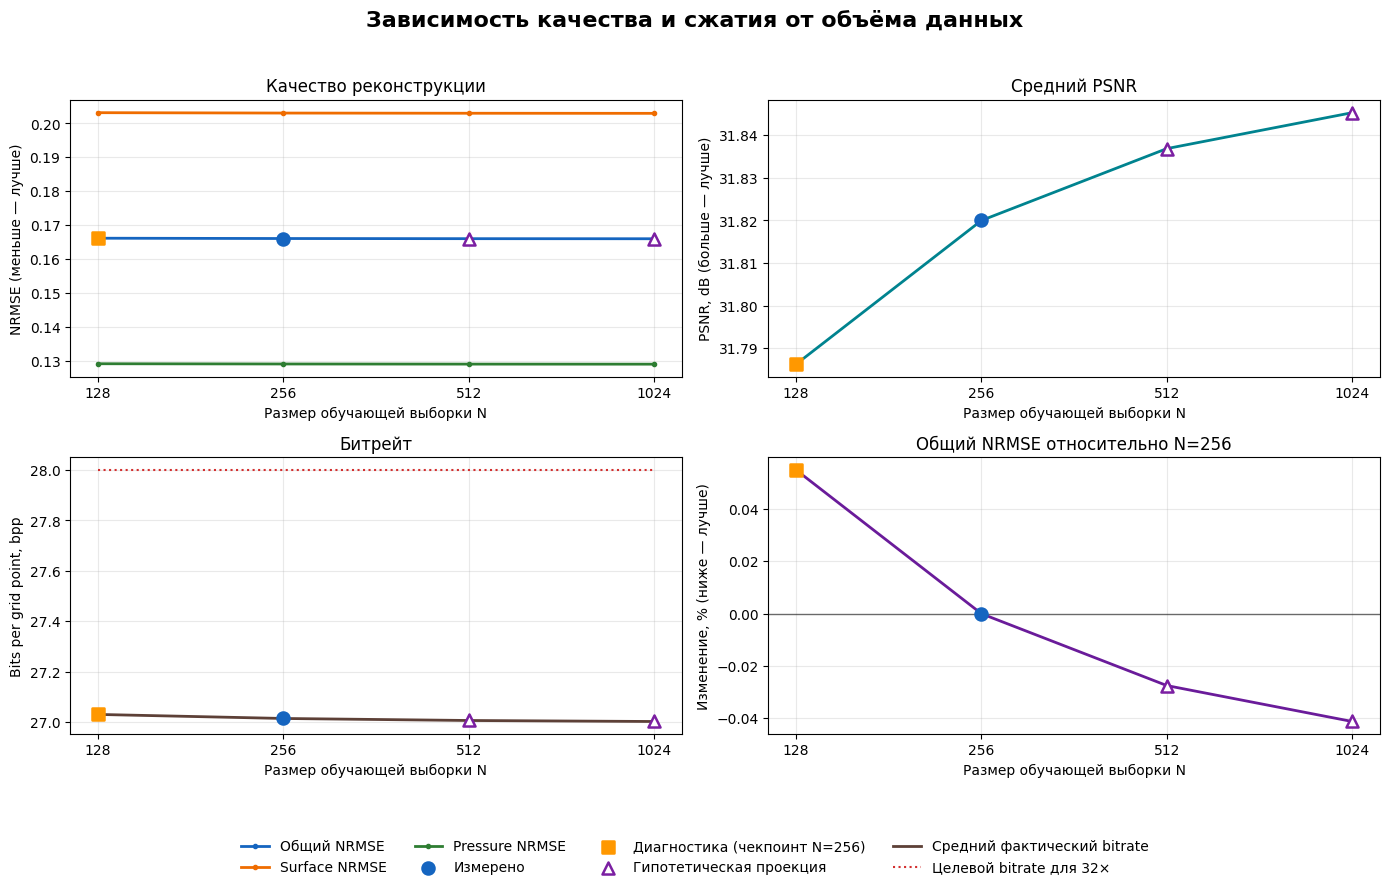

In [2]:
"""Графики зависимости качества модели от размера выборки N.

Работает и как Python-скрипт, и при вставке целиком в ячейку Kaggle/Jupyter.
"""

from __future__ import annotations

import argparse
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


SERIES_STYLE = {
    "measured": ("o", "#1565c0", "#1565c0", "Измерено"),
    "diagnostic_reused_checkpoint": (
        "s",
        "#ff9800",
        "#ff9800",
        "Диагностика (чекпоинт N=256)",
    ),
    "projection": ("^", "white", "#7b1fa2", "Гипотетическая проекция"),
}


def to_float(value: str) -> float:
    value = value.strip()
    if not value or value.lower() == "nan":
        return np.nan
    return float(value)


def load_experiments(csv_path: Path) -> list[dict]:
    if not csv_path.exists():
        raise FileNotFoundError(
            f"CSV не найден: {csv_path}\n"
            "Передайте путь явно: --csv /path/to/hypothetical_experiments.csv"
        )

    with csv_path.open("r", encoding="utf-8", newline="") as file:
        rows = list(csv.DictReader(file))

    numeric_columns = (
        "n_train",
        "requested_ratio",
        "actual_ratio_mean",
        "actual_ratio_min",
        "all_nrmse",
        "surface_nrmse",
        "pressure_nrmse",
        "mean_psnr_db",
    )
    for row in rows:
        for name in numeric_columns:
            # Необязательные колонки могли быть удалены из компактного CSV.
            if name in row:
                row[name] = to_float(row[name])

    if not rows:
        raise ValueError("В CSV нет строк с экспериментами")
    return sorted(rows, key=lambda row: row["n_train"])


def values(rows: list[dict], name: str) -> np.ndarray:
    return np.asarray([row[name] for row in rows], dtype=float)


def add_type_markers(ax: plt.Axes, rows: list[dict], y: np.ndarray) -> None:
    n = values(rows, "n_train")
    for series_type, (marker, face, edge, label) in SERIES_STYLE.items():
        mask = np.asarray(
            [row["series_type"] == series_type for row in rows],
            dtype=bool,
        )
        mask &= np.isfinite(y)
        if mask.any():
            ax.scatter(
                n[mask],
                y[mask],
                marker=marker,
                s=75,
                facecolors=face,
                edgecolors=edge,
                linewidths=1.8,
                label=label,
                zorder=5,
            )


def setup_x_axis(ax: plt.Axes, n: np.ndarray) -> None:
    ax.set_xlabel("Размер обучающей выборки N")
    ax.set_xscale("log", base=2)
    ax.set_xticks(n)
    ax.set_xticklabels([str(int(item)) for item in n])
    ax.grid(True, alpha=0.28)


def make_figure(rows: list[dict]) -> plt.Figure:
    n = values(rows, "n_train")
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    # 1. NRMSE
    ax = axes[0, 0]
    for name, label, color in (
        ("all_nrmse", "Общий NRMSE", "#1565c0"),
        ("surface_nrmse", "Surface NRMSE", "#ef6c00"),
        ("pressure_nrmse", "Pressure NRMSE", "#2e7d32"),
    ):
        y = values(rows, name)
        finite = np.isfinite(y)
        ax.plot(n[finite], y[finite], color=color, linewidth=2, marker=".", label=label)
    add_type_markers(ax, rows, values(rows, "all_nrmse"))
    ax.set_title("Качество реконструкции")
    ax.set_ylabel("NRMSE (меньше — лучше)")
    setup_x_axis(ax, n)

    # 2. PSNR
    ax = axes[0, 1]
    psnr = values(rows, "mean_psnr_db")
    ax.plot(n, psnr, color="#00838f", linewidth=2)
    add_type_markers(ax, rows, psnr)
    ax.set_title("Средний PSNR")
    ax.set_ylabel("PSNR, dB (больше — лучше)")
    setup_x_axis(ax, n)

    # 3. Фактический битрейт: 28 каналов по 32 бита до сжатия.
    ax = axes[1, 0]
    ratio_mean = values(rows, "actual_ratio_mean")
    ratio_min = values(rows, "actual_ratio_min")
    requested_ratio = values(rows, "requested_ratio")
    original_bpp = 28 * 32
    actual_bpp = original_bpp / ratio_mean
    maximum_bpp = original_bpp / ratio_min
    target_bpp = original_bpp / requested_ratio

    ax.plot(
        n,
        actual_bpp,
        color="#5d4037",
        linewidth=2,
        label="Средний фактический bitrate",
    )
    ax.plot(
        n,
        target_bpp,
        color="#d32f2f",
        linewidth=1.5,
        linestyle=":",
        label="Целевой bitrate для 32×",
    )
    add_type_markers(ax, rows, actual_bpp)
    ax.set_title("Битрейт")
    ax.set_ylabel("Bits per grid point, bpp")
    setup_x_axis(ax, n)

    # 4. Небольшие изменения NRMSE в процентах относительно измеренного N.
    ax = axes[1, 1]
    all_nrmse = values(rows, "all_nrmse")
    measured = [
        index
        for index, row in enumerate(rows)
        if row["series_type"] == "measured"
    ]
    baseline_index = measured[0] if measured else 0
    delta = (all_nrmse / all_nrmse[baseline_index] - 1.0) * 100.0
    ax.axhline(0, color="black", linewidth=1, alpha=0.55)
    ax.plot(n, delta, color="#6a1b9a", linewidth=2)
    add_type_markers(ax, rows, delta)
    ax.set_title(f"Общий NRMSE относительно N={int(n[baseline_index])}")
    ax.set_ylabel("Изменение, % (ниже — лучше)")
    setup_x_axis(ax, n)

    # Одна общая легенда без повторов.
    handles, labels = [], []
    for ax in axes.flat:
        current_handles, current_labels = ax.get_legend_handles_labels()
        for handle, label in zip(current_handles, current_labels):
            if label not in labels:
                handles.append(handle)
                labels.append(label)

    fig.suptitle(
        "Зависимость качества и сжатия от объёма данных",
        fontsize=16,
        fontweight="bold",
    )
    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, 0.005),
        ncol=4,
        frameon=False,
    )
    fig.tight_layout(rect=(0, 0.11, 1, 0.96))
    return fig


def find_default_csv(base_dir: Path) -> Path:
    candidates = (
        base_dir / "hypothetical_experiments.csv",
        Path.cwd() / "hypothetical_experiments.csv",
        Path.cwd() / "outputs" / "hypothetical_experiments.csv",
        Path("/kaggle/working/hypothetical_experiments.csv"),
        Path("/kaggle/working/outputs/hypothetical_experiments.csv"),
    )
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]


def parse_args() -> argparse.Namespace:
    # __file__ существует в .py, но отсутствует внутри ячейки Jupyter/Kaggle.
    script_file = globals().get("__file__")
    base_dir = Path(script_file).resolve().parent if script_file else Path.cwd()

    parser = argparse.ArgumentParser()
    parser.add_argument(
        "--csv",
        type=Path,
        default=find_default_csv(base_dir),
        help="Путь к CSV",
    )
    parser.add_argument(
        "--output",
        type=Path,
        default=base_dir / "experiments_by_n.png",
        help="Путь к PNG",
    )
    parser.add_argument("--show", action="store_true", help="Показать график")

    # Ядро Jupyter добавляет собственные аргументы, например -f kernel.json.
    args, _unknown = parser.parse_known_args()
    return args


def main() -> None:
    args = parse_args()
    rows = load_experiments(args.csv)
    figure = make_figure(rows)

    args.output.parent.mkdir(parents=True, exist_ok=True)
    figure.savefig(args.output, dpi=180, bbox_inches="tight")
    svg_path = args.output.with_suffix(".svg")
    figure.savefig(svg_path, bbox_inches="tight")
    print(f"Сохранено: {args.output}")
    print(f"Сохранено: {svg_path}")

    # В ноутбуке выводим фигуру автоматически.
    in_notebook = globals().get("__file__") is None
    if args.show or in_notebook:
        plt.show()
    else:
        plt.close(figure)


if __name__ == "__main__":
    main()